#### Importar las librerías para desarrollar el proyecto

In [14]:
#Importar las librerías

# Análisis de información
import pandas as pd

# Visualización de información
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Guardar la URL del archivo

from google.colab import userdata

### Funciones

#### Importar archivo Excel desde Google Drive

In [2]:
# Función que lee la hoja de cálculo desde la URL

def leer_hoja_google(url, nombre_de_pestaña):
  """
  Esta función lee la hoja de cálculo desde la URL proporcionada y devuelve un DataFrame con los datos.

  Parámetros:
  url (str): La URL de la hoja de cálculo de Google Drive.
  nombre_de_pestaña (str): El nombre de la pestaña de la hoja de cálculo que se desea leer.

  Retorna:
  pd.DataFrame: Un DataFrame con los datos de la hoja de cálculo.
  """
  try:
    nombre_de_hoja = url.split("/d/")[1].split("/")[0]
    csv_url = f"https://docs.google.com/spreadsheets/d/{nombre_de_hoja}/gviz/tq?tqx=out:csv&sheet={nombre_de_pestaña}"
    base_de_datos = pd.read_csv(csv_url)
    print(f"La base de datos ha sido cargada exitosamente")
    return base_de_datos

  except Exception as e:
    print(f"Error al leer la hoja: {e}")
    return None

In [3]:
# Función que devuelve el análisis exploratorio de datos (EDA)

def visualizacion(base_de_datos):
  """
    Esta función devuelve el análisis exploratorio de datos (EDA) de la base de datos proporcionada.

    Parámetros:
    base_pilares (pd.DataFrame): El DataFrame con los datos de la base de datos.

    Retorna:
    None
  """
  print("La base de datos 'Atenciones Marzo-Junio' tiene la siguiente información:")
  print()
  print(base_de_datos.info())
  print()
  print("====================================================================================")
  print("Dimensiones de la base de datos:")
  print()
  print(f"La base tiene {base_de_datos.shape[0]} filas y {base_de_datos.shape[1]} columnas")
  print()
  print("====================================================================================")
  print("La base de datos tiene las siguiente estadísticas:")
  print()
  print(base_de_datos.describe())
  print()
  print("====================================================================================")
  print("La base de datos tiene los siguientes datos ausentes por columna:")
  print()
  print(base_de_datos.isnull().sum())
  print()
  print("====================================================================================")
  print("La base de datos tiene los siguientes porcentajes de datos ausentes por columna:")
  print()

  # Calcular el porcentaje de datos faltantes por columna
  for columna in base_de_datos.columns:
      columna_vacia = base_de_datos[columna].isnull().sum()
      columna_vacia_porc = (columna_vacia / len(base_de_datos)) * 100
      print(f"El porcentaje de datos ausentes para la columna {columna} es: {columna_vacia_porc:.2f}%")
      print()

#### Cargar la base de datos usando la función leer_hoja_google


In [17]:
# Cargar la base de datos y asignar el df de vuelta a un objeto
# URL_analisis_pilares es una variable de entorno guardada en un secreto de Google Colab

URL_pilares = userdata.get("URL_analisis_pilares")
base_pilares = leer_hoja_google(URL_pilares, "Atenciones_Marzo_Junio_2026")

La base de datos ha sido cargada exitosamente


In [5]:
visualizacion(base_pilares)

La base de datos 'Atenciones Marzo-Junio' tiene la siguiente información:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3938 entries, 0 to 3937
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Fecha          3938 non-null   object
 1   Hora           3938 non-null   int64 
 2   Subido         3938 non-null   bool  
 3   Folio          3938 non-null   object
 4   Observaciones  3768 non-null   object
 5   Actividad      3461 non-null   object
 6   Sexo           3177 non-null   object
dtypes: bool(1), int64(1), object(5)
memory usage: 188.6+ KB
None

Dimensiones de la base de datos:

La base tiene 3938 filas y 7 columnas

La base de datos tiene las siguiente estadísticas:

              Hora
count  3938.000000
mean      2.694769
std       1.133138
min       1.000000
25%       2.000000
50%       3.000000
75%       4.000000
max       4.000000

La base de datos tiene los siguientes datos ausentes por columna:

F

#### Conversión de tipo de datos

In [6]:
# Convertir la columna "Fecha" al tipo datetime

base_pilares["Fecha"] = pd.to_datetime(base_pilares["Fecha"], format="%d/%m/%y")
print(f"La columna 'Fecha' es del tipo: {base_pilares['Fecha'].dtype}")

La columna 'Fecha' es del tipo: datetime64[ns]


#### Observación de datos

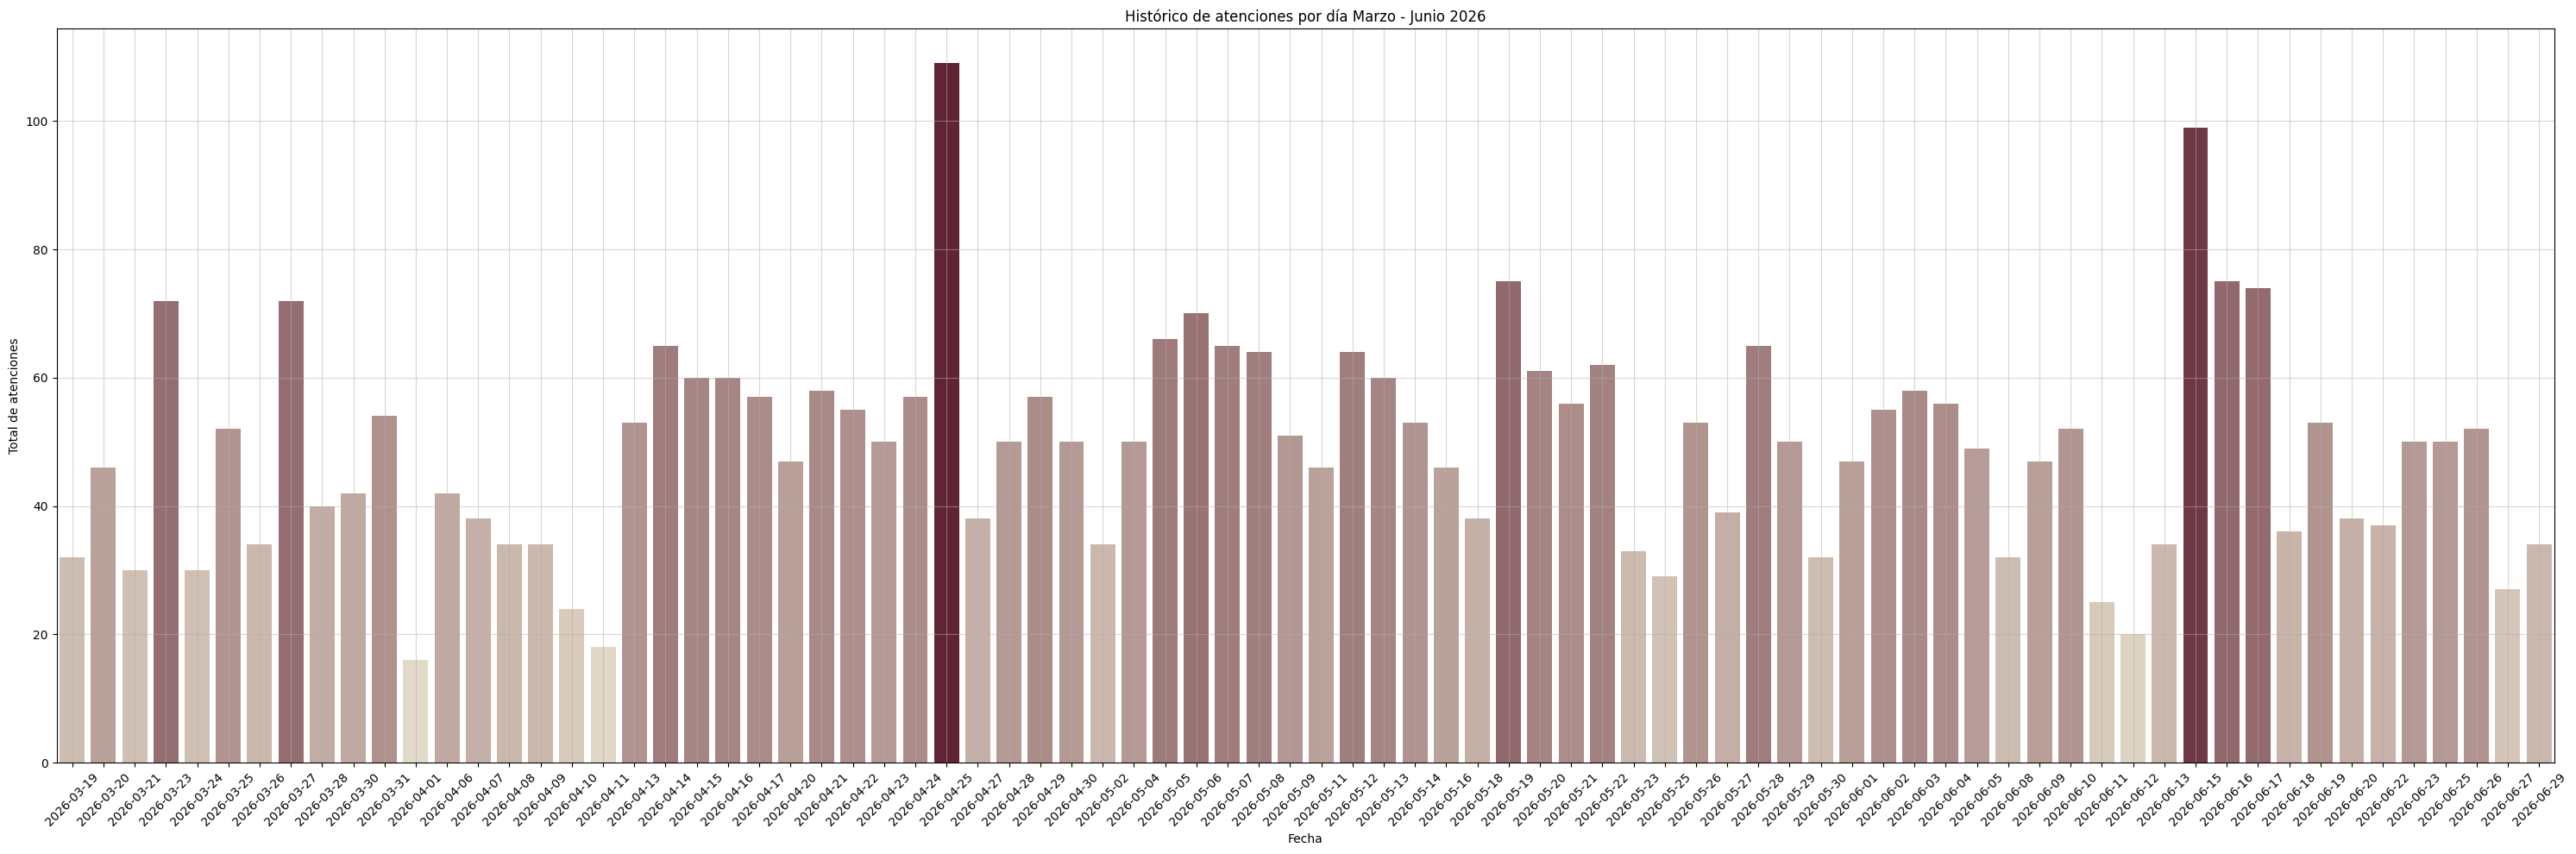

In [7]:
# Histórico de atenciones por día
atenciones_diarias = base_pilares.groupby("Fecha").size().reset_index(drop=False)
atenciones_diarias= atenciones_diarias.rename(columns={
    'Fecha' : 'Fecha',
     0 : 'Total'
    })
atenciones_diarias_df = pd.DataFrame(atenciones_diarias)

# Histórico de atenciones por día (Gráfico)
plt.figure(figsize=(30,10))
sns.barplot(x="Fecha", y="Total", data=atenciones_diarias_df, palette="blend:#E8DCC4,#6A1B31", hue="Total", legend=False)
plt.title("Histórico de atenciones por día Marzo - Junio 2026")
plt.xlabel("Fecha")
plt.ylabel("Total de atenciones")
plt.grid(True, alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

       Fecha  Total
0 2026-04-25    109
1 2026-06-15     99
2 2026-05-19     75
3 2026-06-16     75
4 2026-06-17     74
5 2026-03-23     72
6 2026-03-27     72
7 2026-05-06     70
8 2026-05-05     66
9 2026-05-07     65


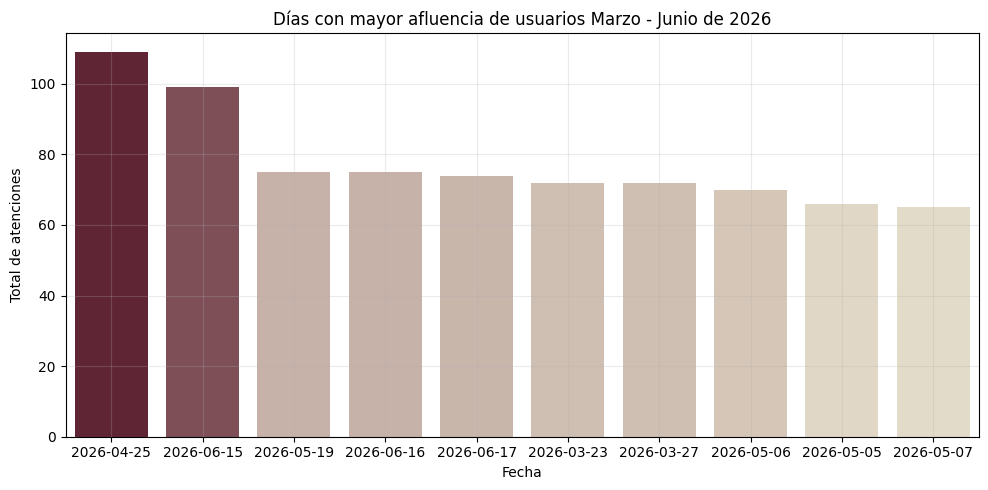

In [8]:
# Días con mayor afluencia de usuarios - Top 10

atenciones_top10 = atenciones_diarias_df.sort_values(by='Total', ascending=False).reset_index(drop=True)
atenciones_top10 = atenciones_top10.head(10)
print(atenciones_top10)

# Días con mayor afluencia de usuarios - Top 10 (Gráfico)
plt.figure(figsize=(10,5))
sns.barplot(x="Fecha", y="Total", data=atenciones_top10, palette="blend:#E8DCC4,#6A1B31", hue="Total", legend=False)
plt.title("Días con mayor afluencia de usuarios Marzo - Junio de 2026")
plt.xlabel("Fecha")
plt.ylabel("Total de atenciones")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

##### **Días con mayor afluencia de usuarios**

En el presente gráfico se observan las atenciones diarias desde el 19 de marzo de 2026 hasta el 29 de junio de 2026.

Las columnas de color más intenso representan los días con mayor afluencia de usuarios en general, mientras que las columnas con colores más tenues representan los días con menor afluencia.

**Los días con mayor afluencia reportados fueron:**

* 25 de abril de 2026: conmemoración del septimo aniversario **(109 atenciones)**
* 15 de junio de 2026: apoyo de registro de alumnos de CETis 167 **(99 atenciones)**
* 19 de mayo de 2026: aplicación del cuarto examen de simulación ECOEMS **(75 atenciones)**
* 16 de junio de 2026: apoyo de actividades alumnos de CETis 167 **(75 atenciones)**
* 17 de junio de 2026: apoyo de actividades alumnos de CETis 167 **(74 atenciones)**

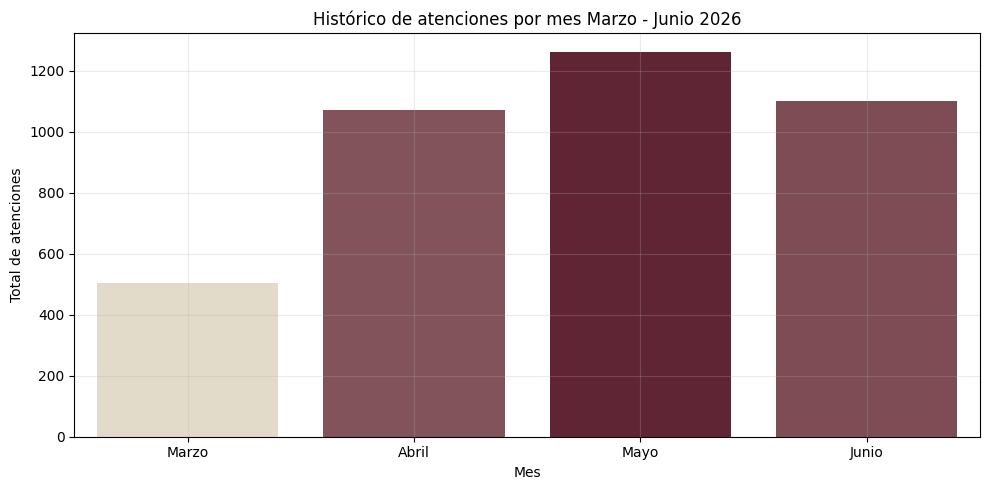

In [9]:
# Visualizar conteo de atenciones por mes

# Agregar la columna "Mes" al dataframe original
base_pilares["Mes"] = base_pilares["Fecha"].dt.month

# Agrupar las atenciones por mes
atenciones_por_mes = base_pilares.groupby("Mes").size().reset_index(drop=False)
atenciones_por_mes = atenciones_por_mes.rename(columns={
    'Mes' : 'Mes',
     0 : 'Total'
    })

# Mapear números de mes a nombre de mes
meses_map = {
    1: "Enero", 2:"Febrero", 3:"Marzo", 4: "Abril",
    5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
    9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}

atenciones_por_mes['Nombre del Mes'] = atenciones_por_mes['Mes'].map(meses_map)

# Histórico de atenciones por mes
plt.figure(figsize=(10,5))
sns.barplot(x="Nombre del Mes", y="Total", data=atenciones_por_mes, palette="blend:#E8DCC4,#6A1B31", hue="Total", legend=False)
plt.title("Histórico de atenciones por mes Marzo - Junio 2026")
plt.xlabel("Mes")
plt.ylabel("Total de atenciones")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()




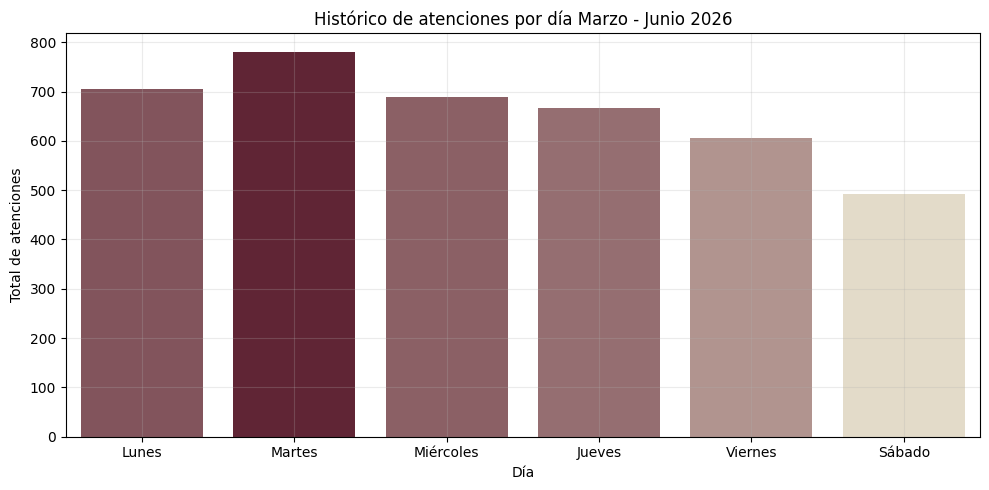

In [10]:
# Visualizar conteo de atenciones por día

# Agregar la columna "Día" al dataframe original
base_pilares["Día"] = base_pilares["Fecha"].dt.weekday

# Agrupar las atenciones por mes
atenciones_por_dia = base_pilares.groupby("Día").size().reset_index(drop=False)
atenciones_por_dia = atenciones_por_dia.rename(columns={
    'Día' : 'Día',
     0 : 'Total'
    })

# Mapear números de día a nombre del día
dias_map = {
    0: "Lunes", 1:"Martes", 2:"Miércoles", 3: "Jueves",
    4: "Viernes", 5: "Sábado", 6: "Domingo"
    }

atenciones_por_dia['Nombre del Día'] = atenciones_por_dia['Día'].map(dias_map)

# Histórico de atenciones por día
plt.figure(figsize=(10,5))
sns.barplot(x="Nombre del Día", y="Total", data=atenciones_por_dia, palette="blend:#E8DCC4,#6A1B31", hue="Total", legend=False)
plt.title("Histórico de atenciones por día Marzo - Junio 2026")
plt.xlabel("Día")
plt.ylabel("Total de atenciones")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()




        Sexo  Total  Porcentaje
0   Femenino   1684       53.01
1  Masculino   1493       46.99


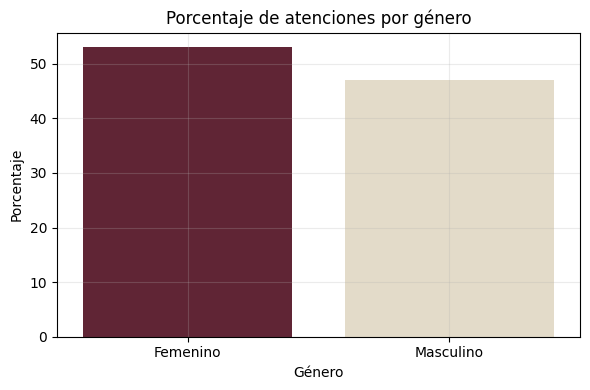

In [11]:
# Visualizar las atenciones por género de usuarios

gen_usuarios = base_pilares.groupby("Sexo").size().reset_index(drop=False)

gen_usuarios = gen_usuarios.rename(columns={
    'Sexo' : 'Sexo',
    0 : 'Total'
})

gen_usuarios["Porcentaje"] = ((gen_usuarios["Total"] / gen_usuarios["Total"].sum())*100).round(2)

print(gen_usuarios)

# Atenciones por género (gráfico)
plt.figure(figsize=(6,4))
sns.barplot(x="Sexo", y="Porcentaje", data=gen_usuarios, palette="blend:#E8DCC4,#6A1B31", hue="Total", legend=False)
plt.title("Porcentaje de atenciones por género")
plt.xlabel("Género")
plt.ylabel("Porcentaje")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


                                           Actividad  Total
0                      Asesorías, Prepa en Línea SEP    966
1                     Asesorías, Examen Único SECTEI    424
2  Asesorías, Ingreso a nivel medio superior (ECO...    363
3  TAC (Tecnologías del Aprendizaje y el Conocimi...    357
4                                Talleres de lenguas    279
5           Asesorías, nivel primaria (Escolarizada)    247
6             Asesorías, Bachillerato (Escolarizado)    236
7                       Asesorías, Prepa Abierta SEP    163
8         Asesorías, nivel secundaria (Escolarizada)    125
9                                   IMSS - Bienestar     58


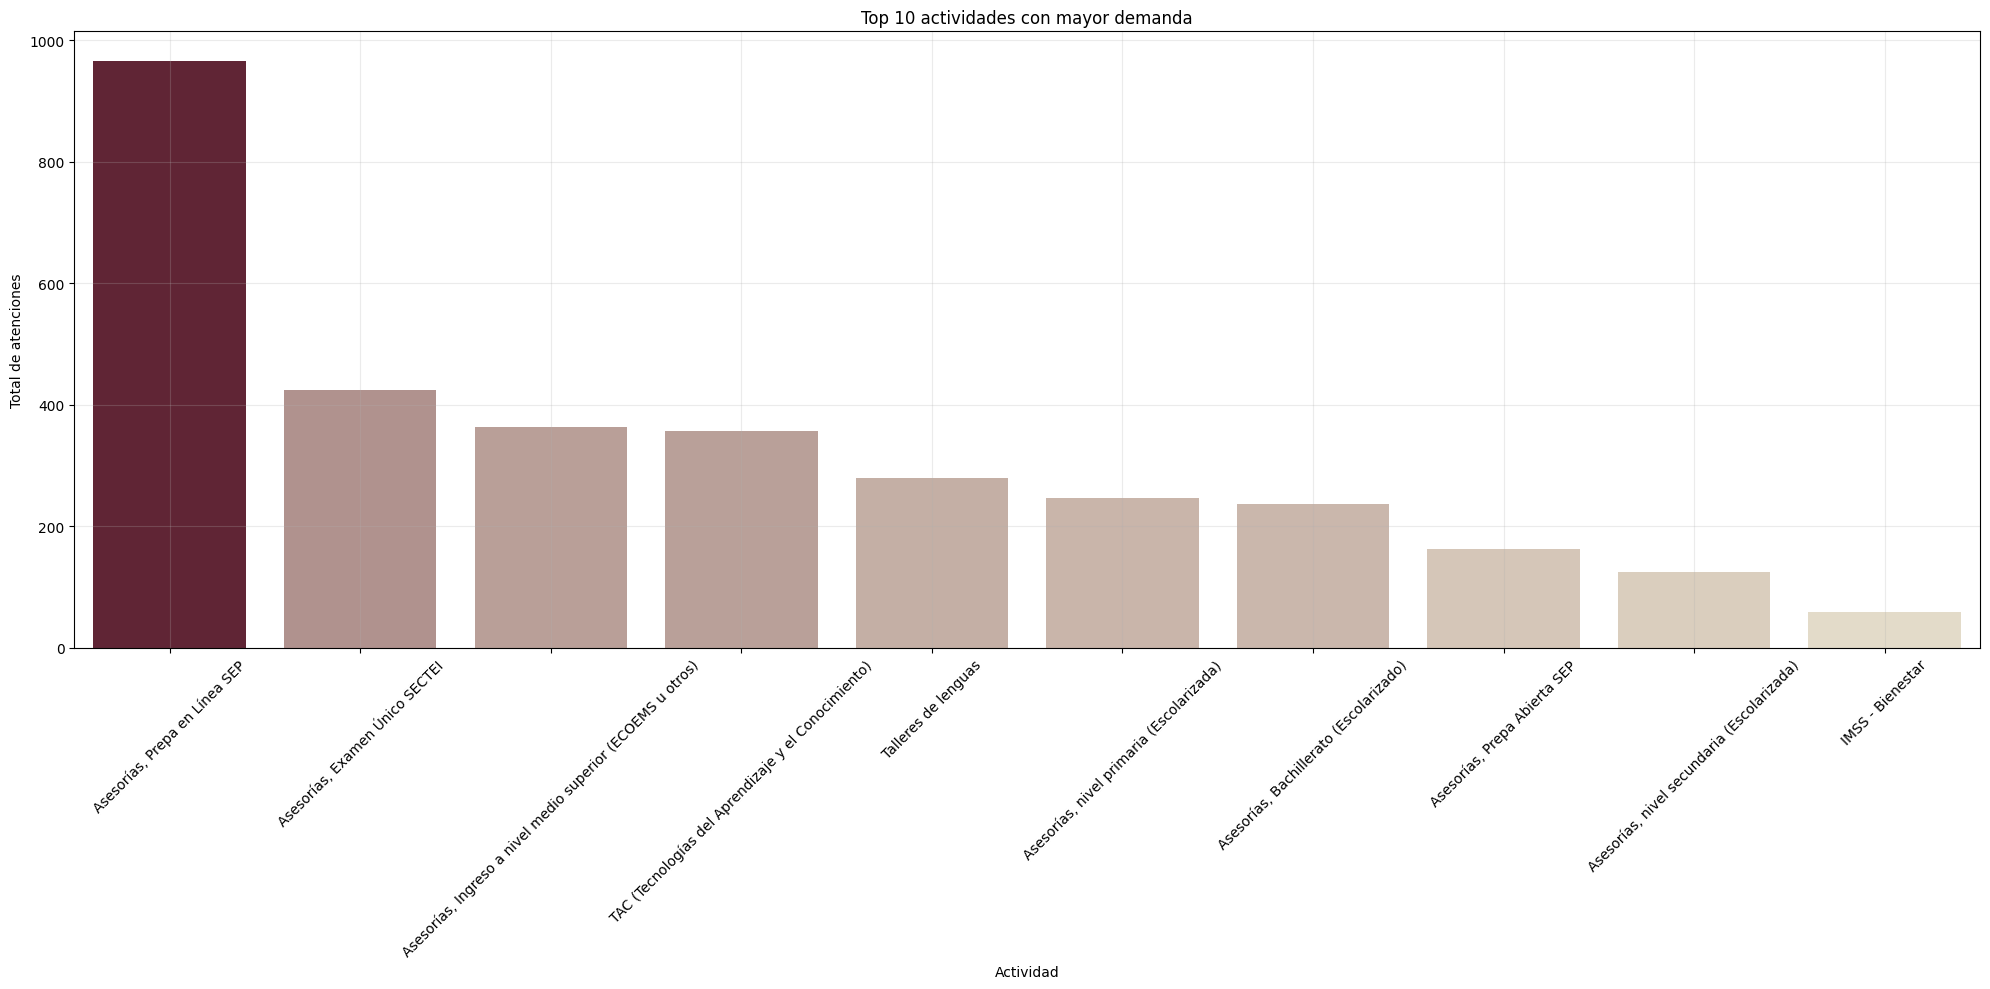

In [12]:
# Visualizar las 10 actividades con mayor demanda

actividades_top10 = base_pilares.groupby("Actividad").size().reset_index(drop=False)

actividades_top10 = actividades_top10.rename(columns={
    "Actividad" : "Actividad",
    0 : "Total"
})

actividades_top10 = actividades_top10.sort_values(by="Total", ascending=False).reset_index(drop=True).head(10)
print(actividades_top10)

#Visualizar los datos en gráfica

plt.figure(figsize=(20,10))
sns.barplot(x="Actividad", y="Total", data=actividades_top10, palette="blend:#E8DCC4,#6A1B31", hue="Total", legend=False)
plt.title("Top 10 actividades con mayor demanda")
plt.xlabel("Actividad")
plt.ylabel("Total de atenciones")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()



                                           Actividad  Total
0                                       universidad       3
1                              Otros bachilleratos        5
2                                     INEA, Primaria      8
3                                   Trámite en línea     22
4     Asesorías, Licenciaturas Tecnológico de México     26
5            Asesoría, Ingreso al nivel licenciatura     29
6                                   INEA, Secundaria     39
7  Asesorías, Certificación de Bachillerato por e...     54
8      Talleres Lúdicos, recreativos y/o Pedagógicos     57
9                                   IMSS - Bienestar     58


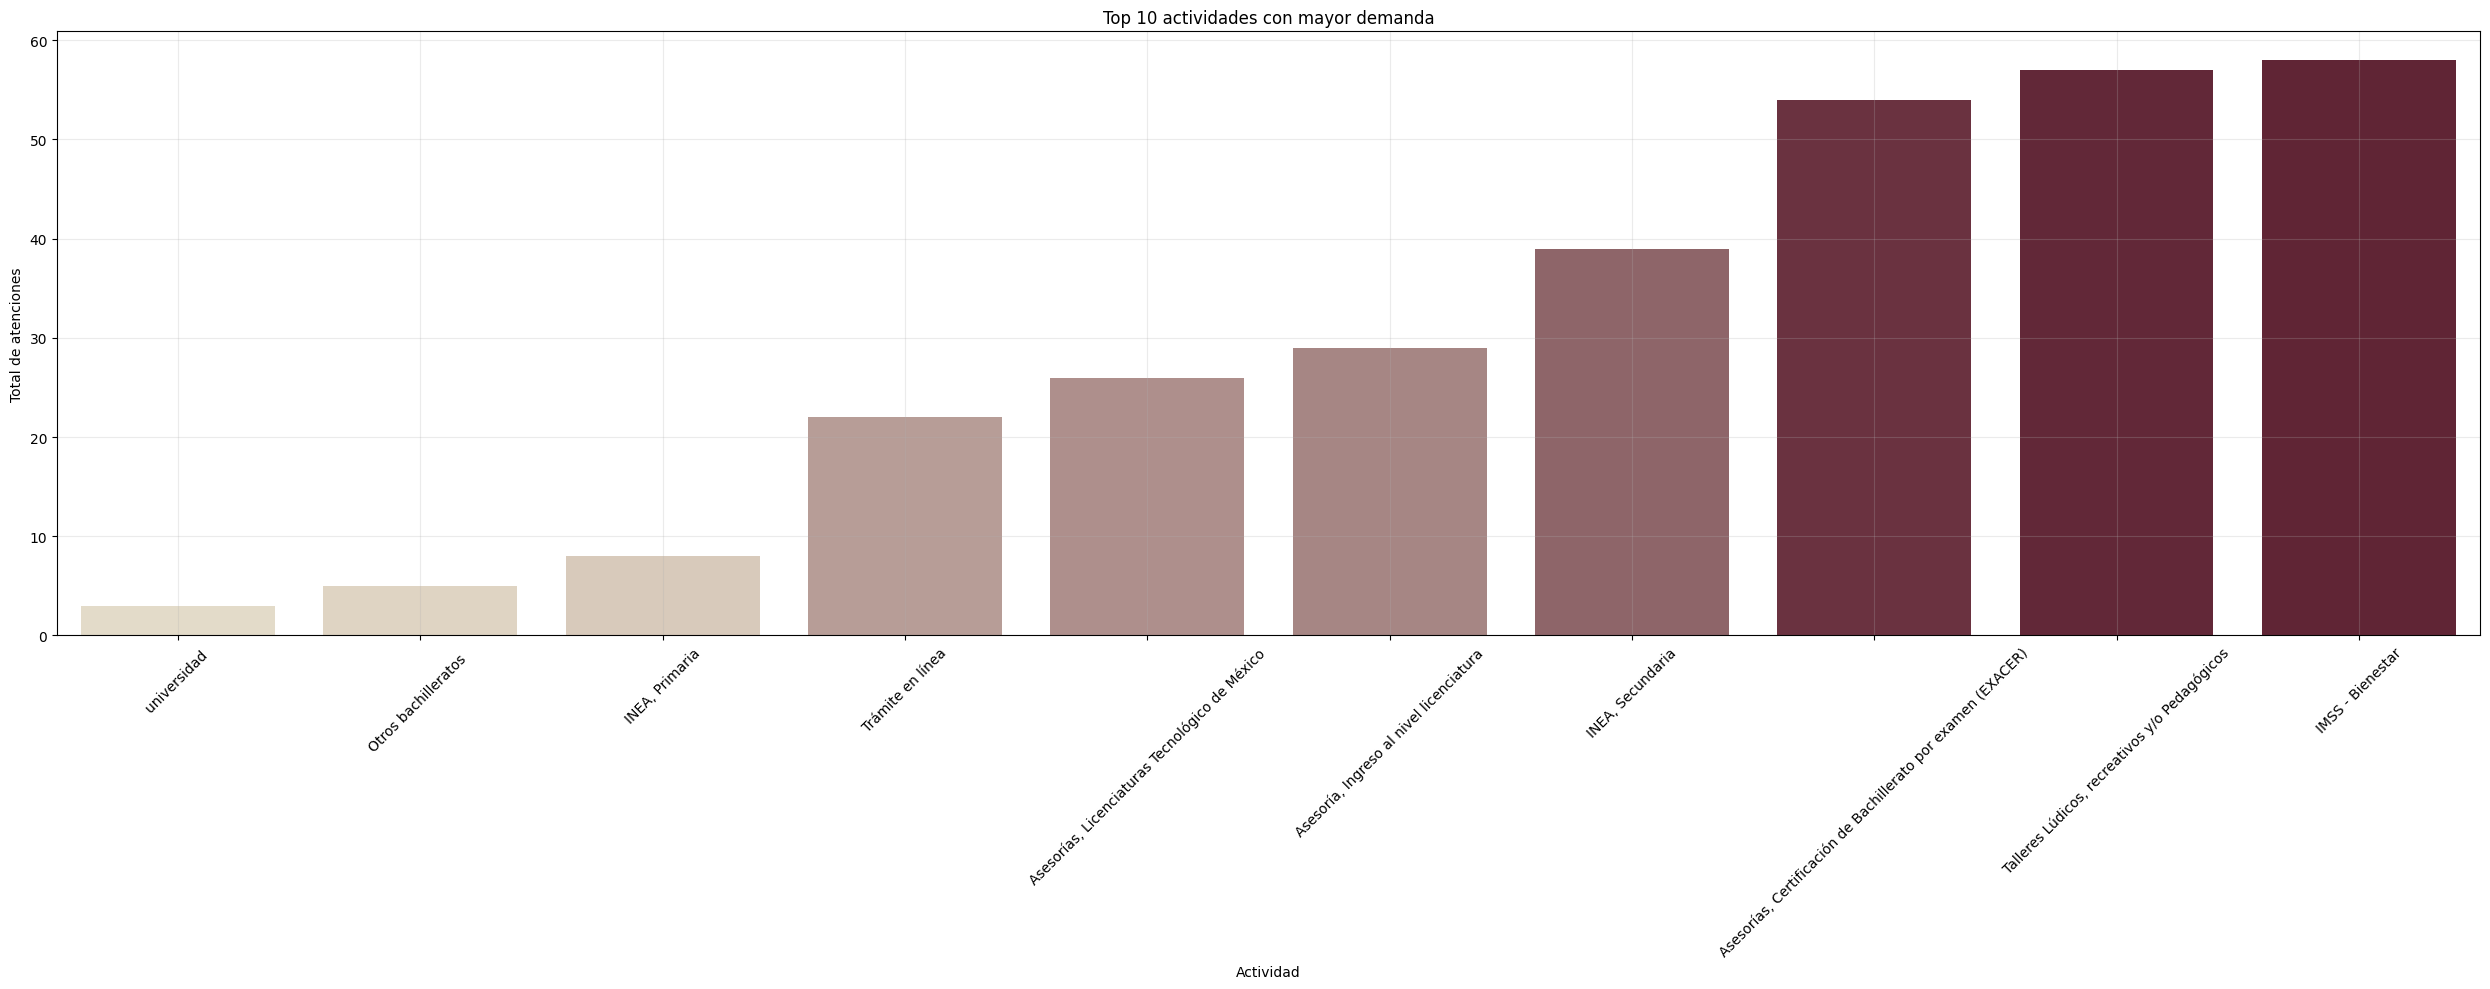

In [13]:
# Visualizar las 10 actividades con menor demanda

actividades_menor_top10 = base_pilares.groupby("Actividad").size().reset_index(drop=False)

actividades_menor_top10 = actividades_menor_top10.rename(columns={
    "Actividad" : "Actividad",
    0 : "Total"
})

actividades_menor_top10 = actividades_menor_top10.sort_values(by="Total", ascending=True).reset_index(drop=True).head(10)
print(actividades_menor_top10)

#Visualizar los datos en gráfica

plt.figure(figsize=(25,10))
sns.barplot(x="Actividad", y="Total", data=actividades_menor_top10, palette="blend:#E8DCC4,#6A1B31", hue="Total", legend=False)
plt.title("Top 10 actividades con mayor demanda")
plt.xlabel("Actividad")
plt.ylabel("Total de atenciones")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()